In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.show()
slk.configs.set_config('ntc_label', 'non-targeting')
print('\n')
slk.configs.show()
slk.configs.reset_config()
slk.configs.get_config('ntc_label')

ntc_label     = NTC
pert_key      = pert
treatment_key = treatment


ntc_label     = non-targeting
pert_key      = pert
treatment_key = treatment


'NTC'

In [4]:
data = sc.read_h5ad("../datasets/raefish/raefish.h5ad")
slk.pp.slk_prepare_data(data, pert_key="RaeFishGene", ntc_label="NonTargeting", treatment_key=None, inplace=True)

AnnData object with n_obs × n_vars = 17931 × 492
    obs: 'dataset', 'fov', 'cell_id', 'cell_type_raw', 'total_merfish', 'total_raefish', 'top1_id', 'top2_id', 'top1_ratio', 'top2_ratio', 'top1_rae_count', 'top2_rae_count', 'RaeFishGene', 'treatment', 'pert'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'merfish_norm'

93 / 551 perturbations (16.9%) occur in exactly one dataset


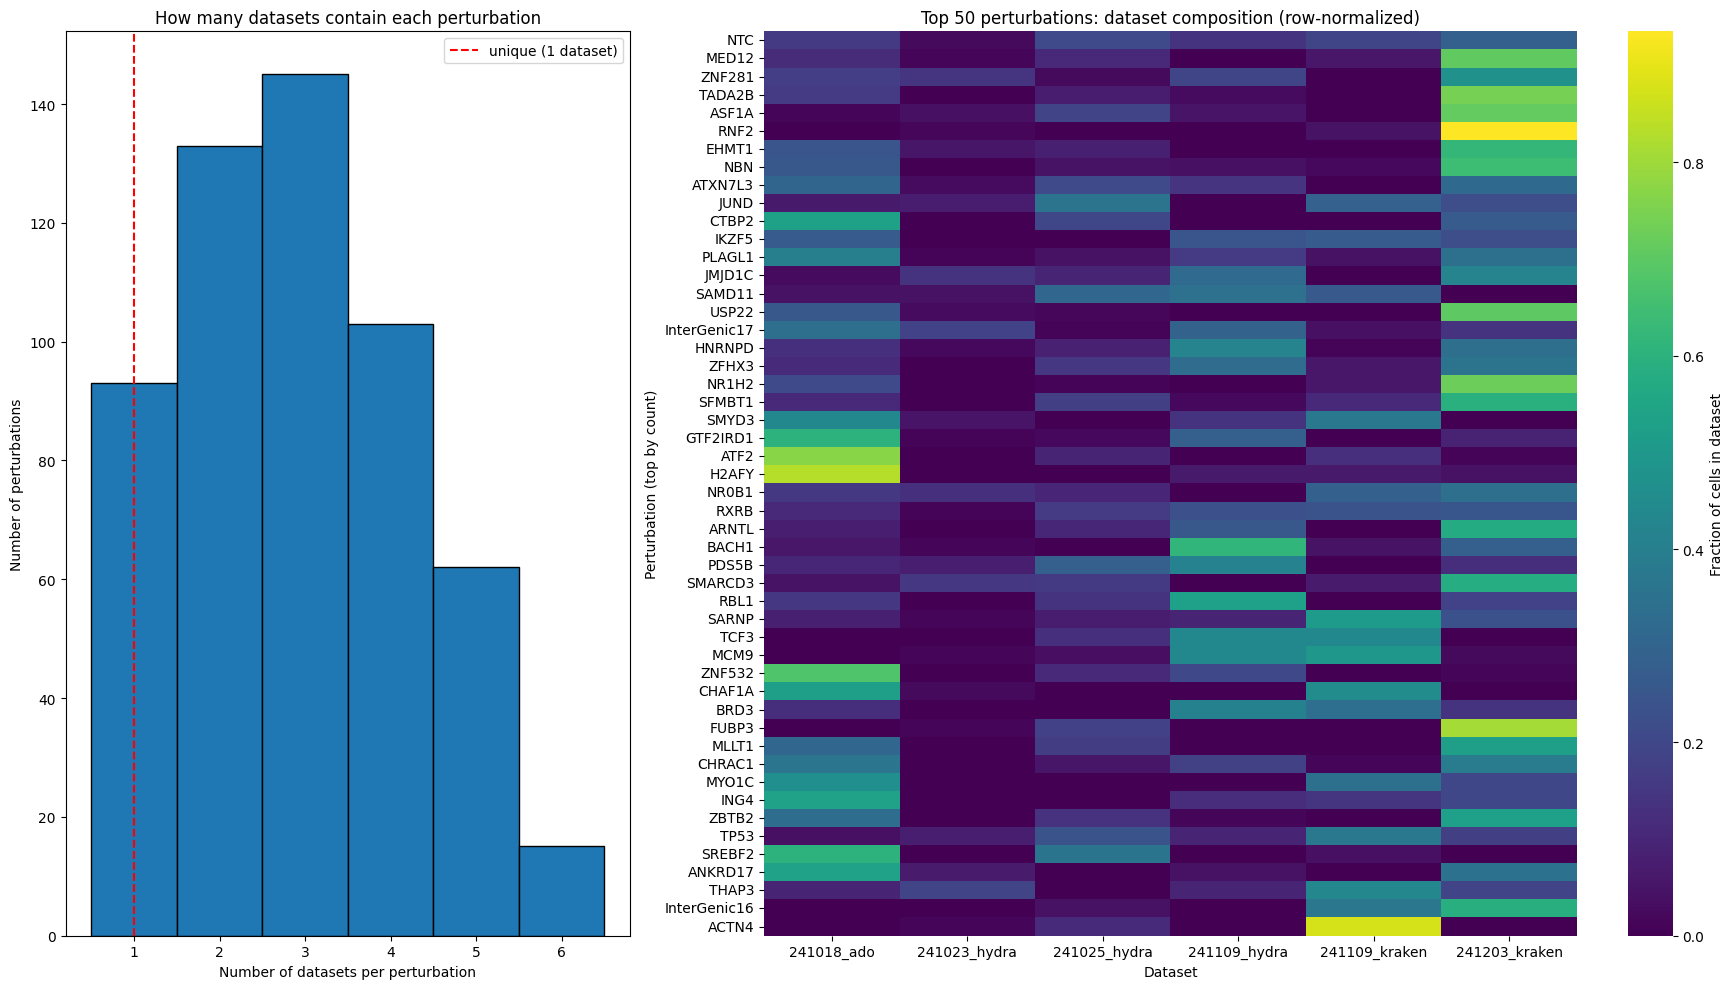

In [5]:
# plot distribution of perturbations across datasets to check dataset-uniqueness
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])  # perturbation x dataset counts
datasets_per_pert = (ct > 0).sum(axis=1)

# summary
n_total = len(datasets_per_pert)
n_unique = (datasets_per_pert == 1).sum()
print(f"{n_unique} / {n_total} perturbations ({n_unique/n_total:.1%}) occur in exactly one dataset")

# figure: histogram of how many datasets each perturbation appears in + heatmap of top perturbations
topN = 50
top_pert = ct.sum(axis=1).sort_values(ascending=False).head(topN).index
ct_top = ct.loc[top_pert]
ct_top_frac = ct_top.divide(ct_top.sum(axis=1), axis=0).fillna(0)  # row-normalized fractions

fig, axes = plt.subplots(1, 2, figsize=(18, 10), gridspec_kw={'width_ratios': [1, 1.8]})

# histogram
axes[0].hist(datasets_per_pert, bins=range(1, datasets_per_pert.max() + 2), color='C0', edgecolor='k', align='left')
axes[0].set_xlabel('Number of datasets per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].axvline(1, color='red', linestyle='--', label='unique (1 dataset)')
axes[0].legend()
axes[0].set_title('How many datasets contain each perturbation')

# heatmap for top perturbations (row-normalized)
sns.heatmap(ct_top_frac, ax=axes[1], cmap='viridis', cbar_kws={'label': 'Fraction of cells in dataset'},
            yticklabels=True)
axes[1].set_ylabel('Perturbation (top by count)')
axes[1].set_xlabel('Dataset')
axes[1].set_title(f'Top {topN} perturbations: dataset composition (row-normalized)')

plt.tight_layout()
plt.show()

/var/tmp/ipykernel_2621841/966415500.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])


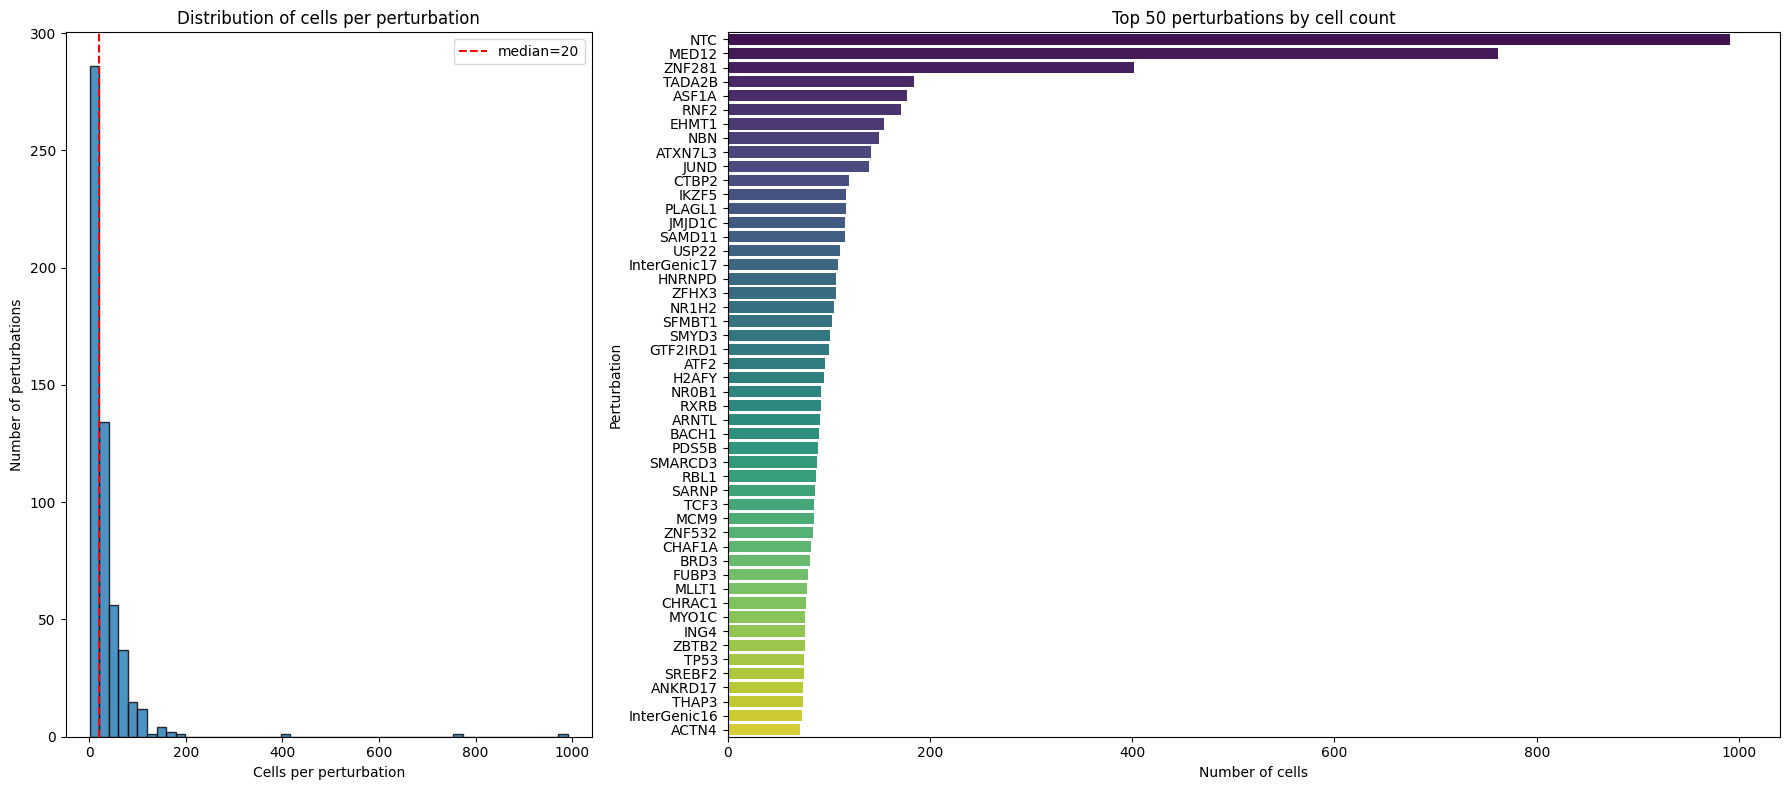

In [6]:
# plot number of cells per perturbation: histogram + top N barplot
pert_counts = ct.sum(axis=1)  # ct is perturbation x dataset counts

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 2]})

# histogram of counts
axes[0].hist(pert_counts.values, bins=50, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Cells per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].set_title('Distribution of cells per perturbation')
axes[0].axvline(pert_counts.median(), color='red', linestyle='--', label=f'median={int(pert_counts.median())}')
axes[0].legend()

# horizontal barplot of top N perturbations
topN = min(50, len(pert_counts))
top = pert_counts.sort_values(ascending=False).head(topN)
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Number of cells')
axes[1].set_ylabel('Perturbation')
axes[1].set_title(f'Top {topN} perturbations by cell count')

plt.tight_layout()
plt.show()

In [7]:
# Cross-tab of counts: rows=perturbations, cols=datasets
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])

# Number of perturbations unique to the dataset
datasets_per_pert = (ct > 0).sum(axis=1)              # in how many datasets each pert appears
unique_perts = datasets_per_pert[datasets_per_pert == 1].index
unique_perts_per_dataset = (ct.loc[unique_perts] > 0).sum(axis=0).reindex(ct.columns, fill_value=0)

# Number of total perturbations in the dataset
total_perts_per_dataset = (ct > 0).sum(axis=0).astype(int)

# Number of cells in the dataset
cells_per_dataset = ct.sum(axis=0).astype(int)

# Average number of cells per perturbation in the dataset
avg_cells_per_pert = (cells_per_dataset / total_perts_per_dataset.replace(0, np.nan)).fillna(0).round(2)

# Assemble a single summary table
summary = pd.DataFrame({
    "unique_perturbations": unique_perts_per_dataset.astype(int),
    "total_perturbations": total_perts_per_dataset.astype(int),
    "cells": cells_per_dataset.astype(int),
    "avg_cells_per_perturbation": avg_cells_per_pert
}).reindex(ct.columns)

print("Per-dataset summary:")
print(summary)


Per-dataset summary:
               unique_perturbations  total_perturbations  cells  \
dataset                                                           
241018_ado                       22                  339   3924   
241023_hydra                      9                  201    961   
241025_hydra                     15                  316   2533   
241109_hydra                     17                  240   2704   
241109_kraken                     9                  203   2467   
241203_kraken                    21                  307   5342   

               avg_cells_per_perturbation  
dataset                                    
241018_ado                          11.58  
241023_hydra                         4.78  
241025_hydra                         8.02  
241109_hydra                        11.27  
241109_kraken                       12.15  
241203_kraken                       17.40  


In [8]:
data = data[data.obs.dataset == '241203_kraken']

/var/tmp/ipykernel_2621841/340320454.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])


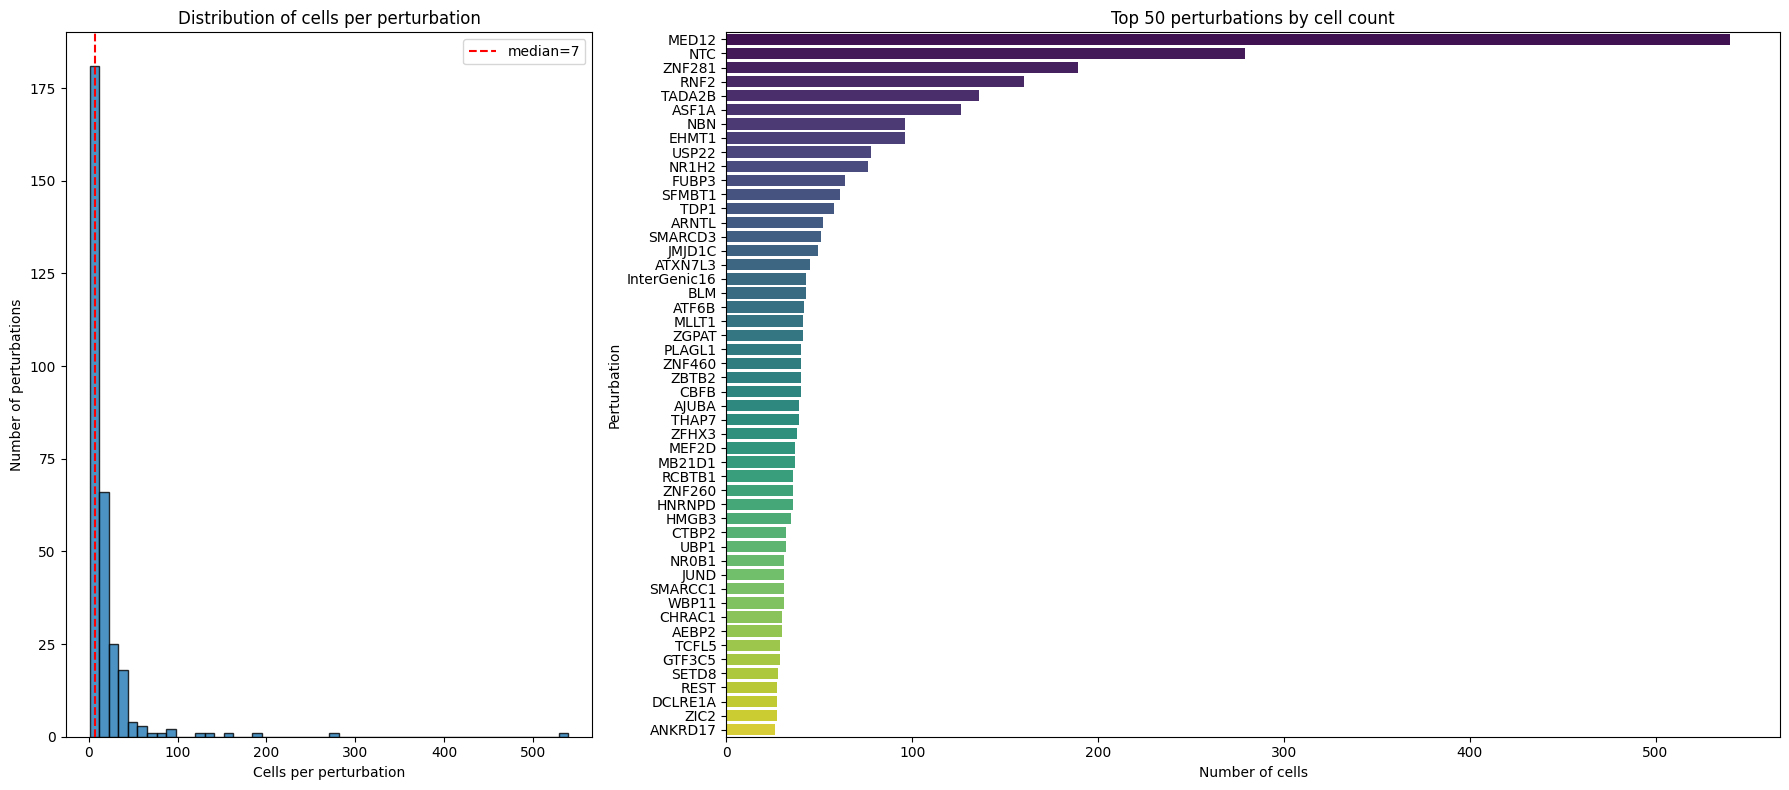

In [9]:
# plot number of cells per perturbation: histogram + top N barplot
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])
pert_counts = ct.sum(axis=1)  # ct is perturbation x dataset counts

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 2]})

# histogram of counts
axes[0].hist(pert_counts.values, bins=50, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Cells per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].set_title('Distribution of cells per perturbation')
axes[0].axvline(pert_counts.median(), color='red', linestyle='--', label=f'median={int(pert_counts.median())}')
axes[0].legend()

# horizontal barplot of top N perturbations
topN = min(50, len(pert_counts))
top = pert_counts.sort_values(ascending=False).head(topN)
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Number of cells')
axes[1].set_ylabel('Perturbation')
axes[1].set_title(f'Top {topN} perturbations by cell count')

plt.tight_layout()
plt.show()

In [10]:
min_cells = 20

# Global counts per perturbation (across all datasets)
pert_counts_full = data.obs['pert'].value_counts()

# Keep perturbations with >= min_cells total cells (ignore per-dataset splits)
valid_perts = pert_counts_full[pert_counts_full >= min_cells].index

mask = data.obs['pert'].isin(valid_perts)
print(f"Keeping {mask.sum()} / {data.n_obs} cells ({mask.sum()/data.n_obs:.1%}) "
      f"from {len(valid_perts)} perturbations (>= {min_cells} cells total)")

# Subset
data = data[mask].copy()

# Recompute summaries
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])
pert_counts = ct.sum(axis=1).astype(int)
datasets_per_pert = (ct > 0).sum(axis=1).astype(int)


Keeping 3898 / 5342 cells (73.0%) from 77 perturbations (>= 20 cells total)


/var/tmp/ipykernel_2621841/340320454.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])


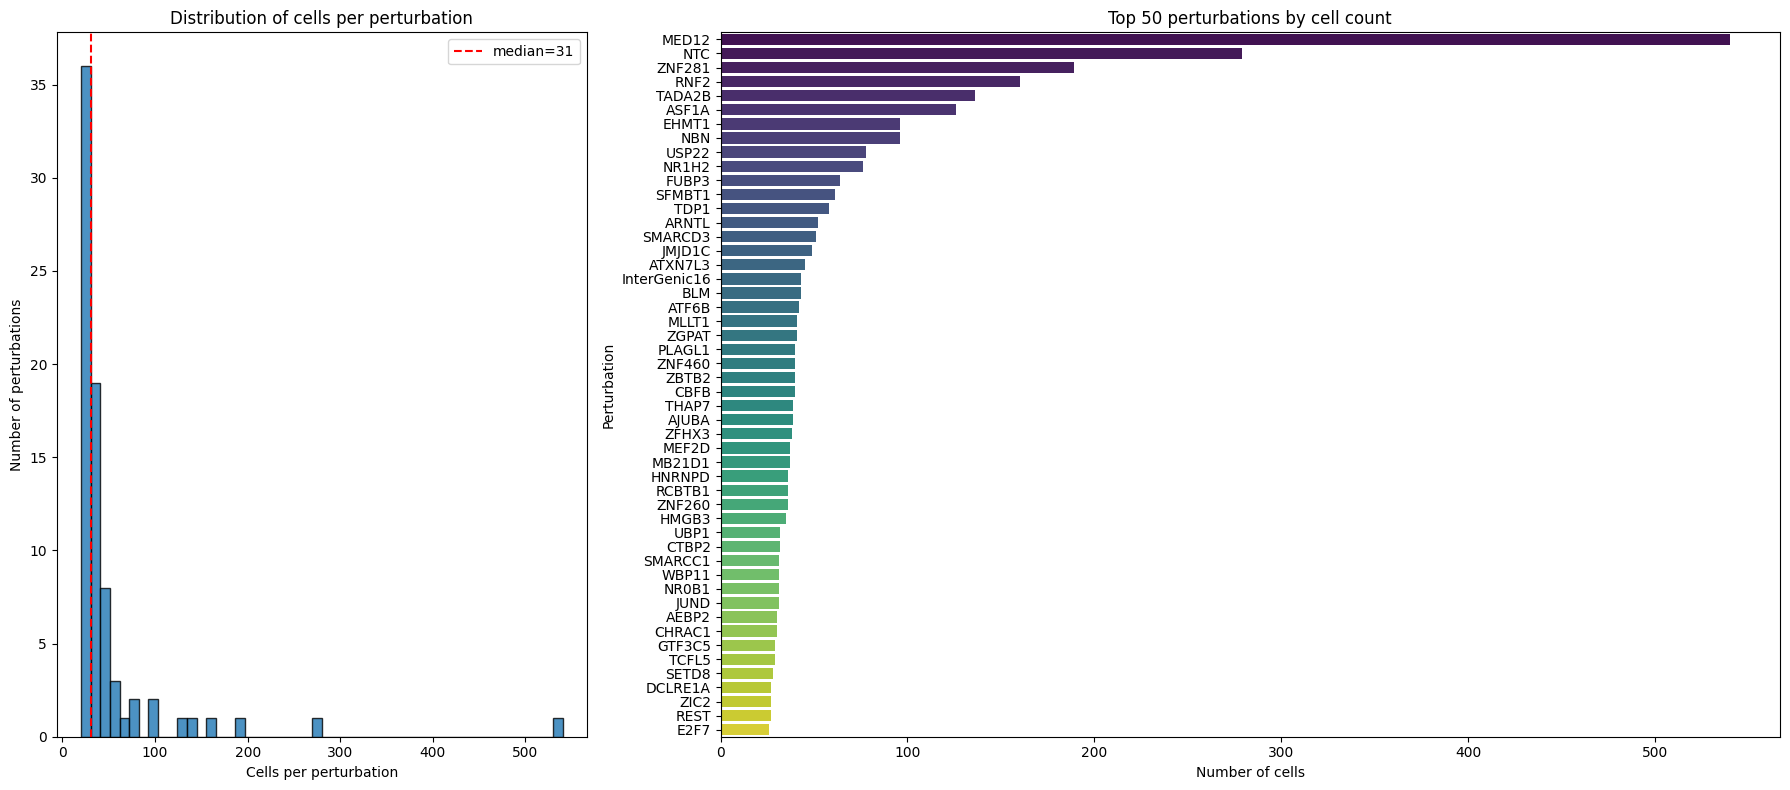

In [11]:
# plot number of cells per perturbation: histogram + top N barplot
ct = pd.crosstab(data.obs['pert'], data.obs['dataset'])
pert_counts = ct.sum(axis=1)  # ct is perturbation x dataset counts

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 2]})

# histogram of counts
axes[0].hist(pert_counts.values, bins=50, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_xlabel('Cells per perturbation')
axes[0].set_ylabel('Number of perturbations')
axes[0].set_title('Distribution of cells per perturbation')
axes[0].axvline(pert_counts.median(), color='red', linestyle='--', label=f'median={int(pert_counts.median())}')
axes[0].legend()

# horizontal barplot of top N perturbations
topN = min(50, len(pert_counts))
top = pert_counts.sort_values(ascending=False).head(topN)
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Number of cells')
axes[1].set_ylabel('Perturbation')
axes[1].set_title(f'Top {topN} perturbations by cell count')

plt.tight_layout()
plt.show()

/var/tmp/ipykernel_2621841/1378270000.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/tmp/ipykernel_2621841/1378270000.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


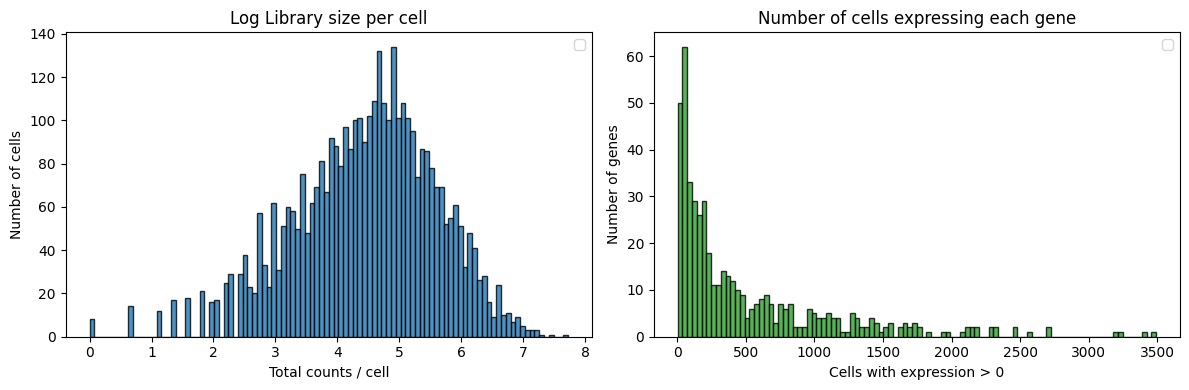

In [12]:
import scipy.sparse as sps

# fallback: sum across expression matrix
lib_size = np.asarray(data.X.sum(axis=1)).ravel()

# 2) number of cells per gene (non-zero counts)
X = data.X
if sps.issparse(X):
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    cells_per_gene = (X > 0).sum(axis=0).astype(int)

# 3) Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Library size histogram
axes[0].hist(np.log(lib_size+1), bins=100, color='C0', edgecolor='k', alpha=0.8)
axes[0].set_title('Log Library size per cell')
axes[0].set_xlabel('Total counts / cell')
axes[0].set_ylabel('Number of cells')
axes[0].legend()

# Cells per gene histogram
axes[1].hist(cells_per_gene, bins=100, color='C2', edgecolor='k', alpha=0.8)
axes[1].set_title('Number of cells expressing each gene')
axes[1].set_xlabel('Cells with expression > 0')
axes[1].set_ylabel('Number of genes')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# filter cells by log1p(lib_size) > 3 and subset to highly variable genes
cell_mask = np.log(lib_size + 1) > 3
print(f"Keeping {cell_mask.sum()} / {data.n_obs} cells (log1p(lib_size) > 3)")

data = data[cell_mask].copy()

Keeping 3436 / 3898 cells (log1p(lib_size) > 3)


In [14]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

  0%|          | 0/76 [00:00<?, ?it/s]

100%|██████████| 76/76 [00:00<00:00, 227.53it/s]


In [229]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, 
                            batch_size=4096,
                             shuffle=True, 
                             num_workers=0, 
                             device=device, 
                             ce_lambda=1e-3, 
                             num_epochs=1000,
                             l0_lambda=10,
                             latent_dim=16,
                             patience=1000,
                             ntc_lambda=1e-7,
                             pert_lambda=1e8,
                             rank=6,
                             gate_init_p=0.5,
                             tau_init=0.5,
                             tau_end=0.1,
                             shift='linear'
                             )

Training VAE on cuda …


Epochs: 100%|██████████| 1000/1000 [01:59<00:00,  8.35it/s, ATE=0.3692, CE=0.3077, ELBO=387.4312, R2_ntc=0.8527, R2_p=0.5800, acc=0.904, pi25=0.32, pi99=0.67, tau=0.100]


In [230]:
slk.tl.save_results(results, '../results/raefish.pth')

In [231]:
model = slk.tl.load_results('../results/raefish.pth')

In [232]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results")

In [233]:
data.uns['results']

{'acc': 0.9990604519844055,
 'rho_corr': array([[ 1.0000001 ,  0.0199651 ,  0.08826346, ...,  0.25709185,
         -0.34976795, -0.4114987 ],
        [ 0.0199651 ,  1.        ,  0.12999587, ...,  0.21440545,
          0.28774095, -0.0920547 ],
        [ 0.08826346,  0.12999587,  1.        , ...,  0.7020945 ,
          0.23186332, -0.32498184],
        ...,
        [ 0.25709185,  0.21440545,  0.7020945 , ...,  1.0000001 ,
          0.5484299 ,  0.09203696],
        [-0.34976795,  0.28774095,  0.23186332, ...,  0.5484299 ,
          1.0000001 ,  0.6701598 ],
        [-0.4114987 , -0.0920547 , -0.32498184, ...,  0.09203696,
          0.6701598 ,  0.99999994]], shape=(76, 76), dtype=float32),
 'z_corr': array([[1.        , 0.46113428, 0.41551572, ..., 0.32597426, 0.1168415 ,
         0.12131323],
        [0.46113428, 0.9999999 , 0.56022346, ..., 0.5204373 , 0.64309555,
         0.44688454],
        [0.41551572, 0.5602234 , 1.        , ..., 0.3461739 , 0.30224496,
         0.5958406 ],
    

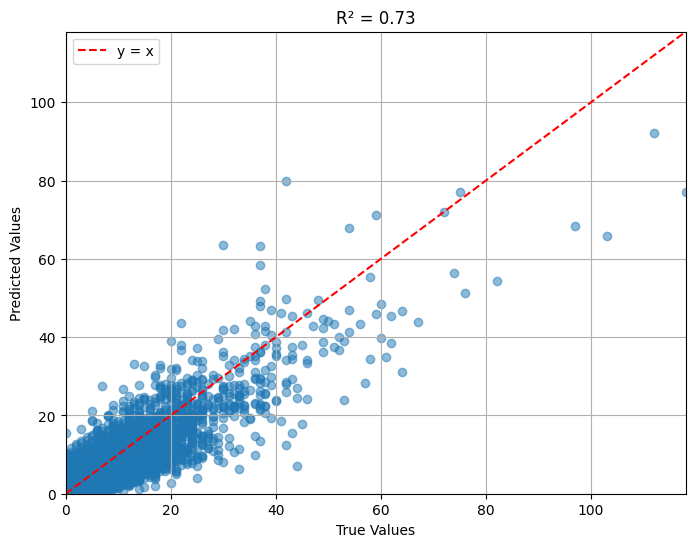

In [234]:
slk.pl.plot_r2(data)

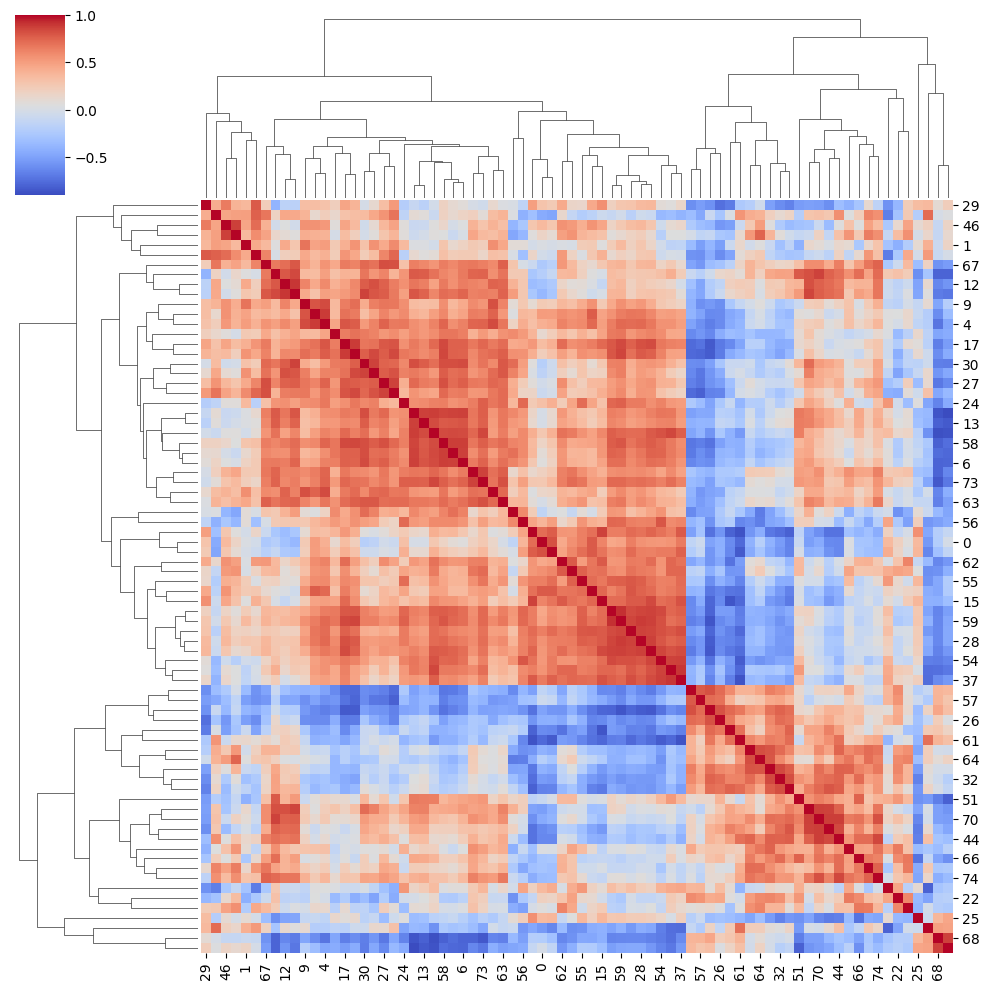

In [235]:
slk.pl.plot_corr(data)

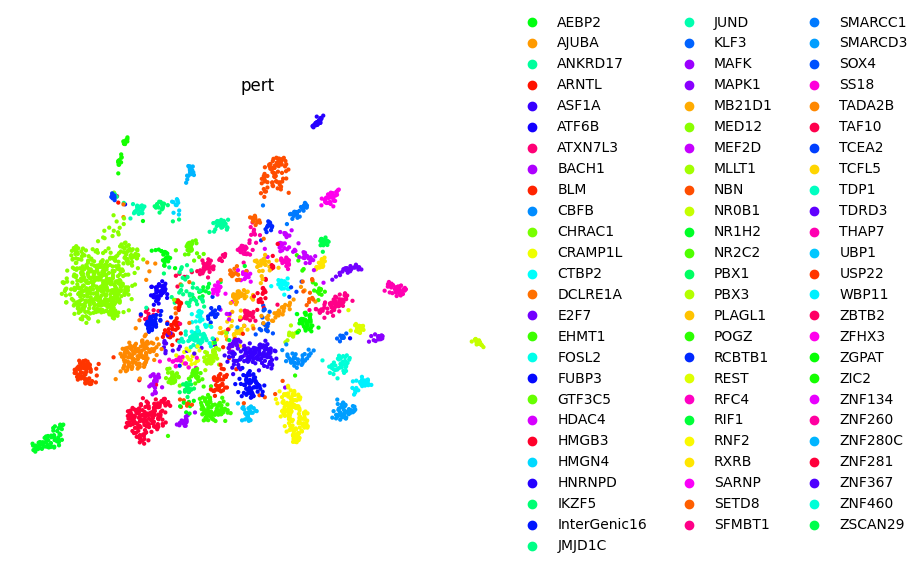

In [236]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

In [237]:
zrc = data.uns['results']['z_rho_corr']

print(f"Spearman ρ = {zrc['spearman_r']:.3f}  (p = {zrc['spearman_p']:.1e})")
print(f" Pearson  r = {zrc['pearson_r']:.3f}  (p = {zrc['pearson_p']:.1e})") 

Spearman ρ = 0.791  (p = 0.0e+00)
 Pearson  r = 0.801  (p = 0.0e+00)


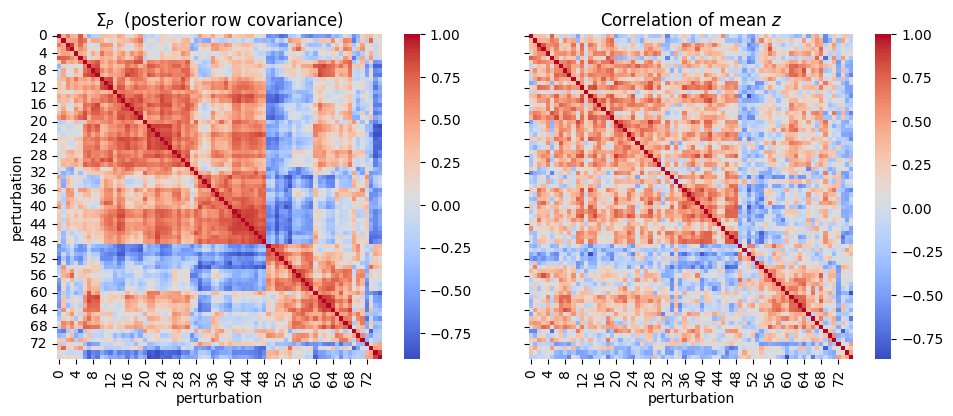

In [238]:
slk.pl.plot_zcorr(data)

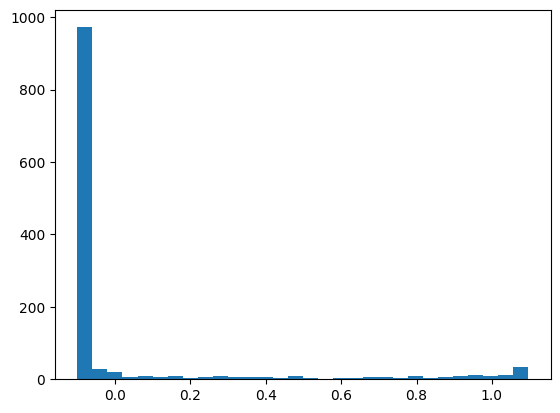

In [239]:
W = data.uns['results']['W']
plt.hist(W.flatten(), bins=30)
plt.show()

<Axes: >

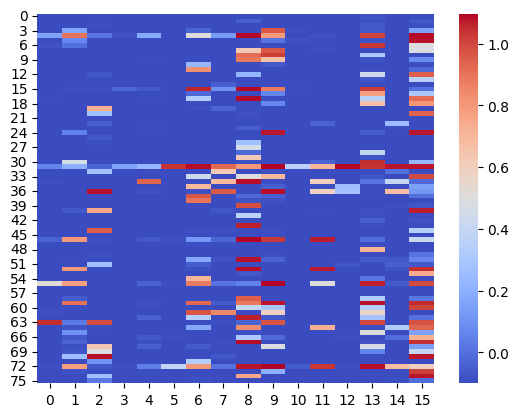

In [240]:
W_bin = (W > 0.5).astype(float)
sns.heatmap(W, cmap="coolwarm")

In [241]:

dataset = slk.tl.PerturbMatchingDataset(data)
all_genes = dataset.perturbation_dict.keys()

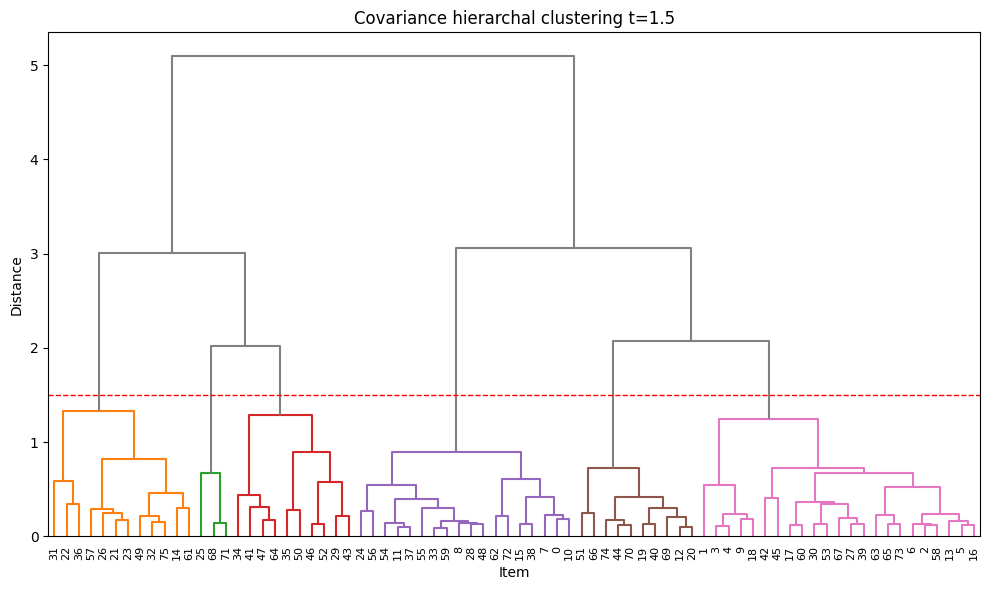

In [242]:
groups = slk.tl.cluster_rho(data, t=1.5, show=True)

In [243]:
#for a non subsetted data, pass in genes corresponding to idx ie dataset.perturbation_dict.keys()
named_groups = slk.tl.group2name(groups, all_genes)
named_groups

,group
AEBP2,4
AJUBA,6
ANKRD17,6
ARNTL,6
ASF1A,6
...,...
ZNF280C,2
ZNF281,4
ZNF367,6
ZNF460,5


pert_group
1    809
2     85
3    450
4    789
5    273
6    787
Name: count, dtype: int64


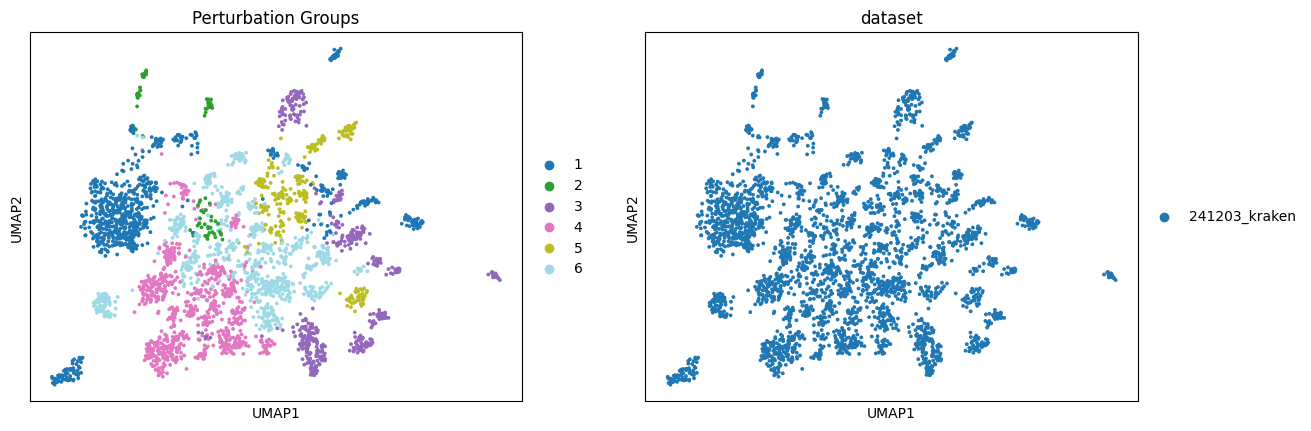

In [244]:
# map perturbation -> group using named_groups (index=gene, column='group')
gene_to_group = named_groups['group'].to_dict()

# assign group to obs based on slk pert key
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
sub.obs['pert_group'] = sub.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(sub.obs['pert_group'].value_counts().sort_index())

sc.pl.umap(sub, color=['pert_group', 'dataset'], title='Perturbation Groups', palette='tab20', size=30)

In [245]:
for i in sub.obs.pert_group.unique():
    print(i)
    print(sub[sub.obs.pert_group == i].obs['pert'].value_counts())

4
pert
ZNF281          163
TADA2B          126
EHMT1            86
TDP1             53
BLM              42
InterGenic16     37
MLLT1            36
UBP1             30
AEBP2            29
CHRAC1           26
BACH1            25
NR2C2            22
PBX1             21
CRAMP1L          19
TAF10            19
SARNP            19
MAFK             18
SS18             18
Name: count, dtype: int64
6
pert
ASF1A      114
USP22       67
FUBP3       60
ARNTL       46
ATF6B       41
ATXN7L3     40
ZGPAT       39
AJUBA       35
CBFB        34
MB21D1      31
RCBTB1      30
GTF3C5      28
TCFL5       28
ANKRD17     26
ZBTB2       26
TDRD3       24
DCLRE1A     24
FOSL2       21
SOX4        17
ZNF367      17
PBX3        15
RIF1        15
KLF3         9
Name: count, dtype: int64
1
pert
MED12      509
NR1H2       70
THAP7       37
MEF2D       31
E2F7        26
SETD8       25
HNRNPD      25
JUND        24
IKZF5       20
ZSCAN29     19
TCEA2       13
HMGN4       10
Name: count, dtype: int64
5
pert
ZNF460   

In [246]:
# Print gene symbols per group, one gene per line (no quotation marks)
grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())

for grp in sorted(grouped.index):
    print(f"Group {grp}:")
    for gene in grouped.loc[grp]:
        print(gene)
    print()

Group 1:
E2F7
HMGN4
HNRNPD
IKZF5
JUND
MED12
MEF2D
NR1H2
SETD8
TCEA2
THAP7
ZSCAN29

Group 2:
JMJD1C
ZIC2
ZNF280C

Group 3:
MAPK1
NBN
NR0B1
POGZ
REST
RNF2
RXRB
SFMBT1
SMARCD3
WBP11

Group 4:
AEBP2
BACH1
BLM
CHRAC1
CRAMP1L
EHMT1
InterGenic16
MAFK
MLLT1
NR2C2
PBX1
SARNP
SS18
TADA2B
TAF10
TDP1
UBP1
ZNF281

Group 5:
CTBP2
HDAC4
HMGB3
PLAGL1
RFC4
SMARCC1
ZFHX3
ZNF134
ZNF260
ZNF460

Group 6:
AJUBA
ANKRD17
ARNTL
ASF1A
ATF6B
ATXN7L3
CBFB
DCLRE1A
FOSL2
FUBP3
GTF3C5
KLF3
MB21D1
PBX3
RCBTB1
RIF1
SOX4
TCFL5
TDRD3
USP22
ZBTB2
ZGPAT
ZNF367



/var/tmp/ipykernel_2621841/2222304912.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())
